In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\AppliedMachineLearning Project\Non-alcoholic fatty liver dataset.csv")
df.head()

,Patient ID,sex,Age,Height,Weight,BMI,waist,Fasting Blood sugar,Cre,Urea,...,Ferritin,Insulin,CRP,Vitamin A,OH,Steatosis stage,CAP score,E score,Fibroscan S,Fibroscan F
0,TAL01331,M,34,186,96.0,27.7,102.0,102,1.00,30,...,131.51,19.55,2.2,57.0,25.0,3,310.0,5.3,3,1
1,TAL02130,M,48,173,88.0,29.0,103.0,104,1.00,30,...,158.00,10.00,1.0,29.0,25.0,1,289.0,3.6,3,0
2,TAL03101,M,52,173,88.0,29.0,103.0,99,1.14,38,...,271.00,10.00,2.0,29.0,25.0,1,237.0,4.5,0,1
3,TAL04102,F,68,173,88.0,29.0,103.0,98,1.00,30,...,158.00,10.00,1.0,29.0,25.0,1,240.0,9.0,0,2
4,TAL05211,F,68,173,88.0,29.0,103.0,100,1.00,30,...,158.00,10.00,2.0,29.0,25.0,2,260.0,6.0,1,1


In [7]:
# ===========================================
# 📦 1. Import Required Libraries
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, RocCurveDisplay, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from joblib import dump
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid', palette='muted', font_scale=1.1)

In [8]:
# Use raw string path for Windows directory
data_path = r"C:\Users\USER\OneDrive\Desktop\AppliedMachineLearning Project\Non-alcoholic fatty liver dataset.csv"

# Load dataset
df = pd.read_csv(data_path)

# Display first few rows
df.head()

,Patient ID,sex,Age,Height,Weight,BMI,waist,Fasting Blood sugar,Cre,Urea,...,Ferritin,Insulin,CRP,Vitamin A,OH,Steatosis stage,CAP score,E score,Fibroscan S,Fibroscan F
0,TAL01331,M,34,186,96.0,27.7,102.0,102,1.00,30,...,131.51,19.55,2.2,57.0,25.0,3,310.0,5.3,3,1
1,TAL02130,M,48,173,88.0,29.0,103.0,104,1.00,30,...,158.00,10.00,1.0,29.0,25.0,1,289.0,3.6,3,0
2,TAL03101,M,52,173,88.0,29.0,103.0,99,1.14,38,...,271.00,10.00,2.0,29.0,25.0,1,237.0,4.5,0,1
3,TAL04102,F,68,173,88.0,29.0,103.0,98,1.00,30,...,158.00,10.00,1.0,29.0,25.0,1,240.0,9.0,0,2
4,TAL05211,F,68,173,88.0,29.0,103.0,100,1.00,30,...,158.00,10.00,2.0,29.0,25.0,2,260.0,6.0,1,1


In [9]:
# Check dataset shape and basic info
print("Dataset shape:", df.shape)
df.info()

# Check for missing values
df.isnull().sum().sort_values(ascending=False).head(20)

Dataset shape: (113, 62)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 62 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient ID            113 non-null    object 
 1   sex                   113 non-null    object 
 2   Age                   113 non-null    int64  
 3   Height                113 non-null    int64  
 4   Weight                113 non-null    float64
 5   BMI                   113 non-null    float64
 6   waist                 113 non-null    float64
 7   Fasting Blood sugar   113 non-null    int64  
 8   Cre                   113 non-null    float64
 9   Urea                  113 non-null    int64  
 10  Uric Acid             113 non-null    float64
 11  Triglyceride          113 non-null    int64  
 12  Cholestrol            113 non-null    int64  
 13  HDL                   113 non-null    int64  
 14  LDL                   113 non-null    int64  
 15

CAP score      19
E score        17
Patient ID      0
Control PT      0
Platelets       0
Neutrophil      0
Lymphocyte      0
Monocyte        0
Eosinophil      0
basophil        0
Neutrophil%     0
Lymphocyte%     0
Monocyte%       0
Eosinophil%     0
Basophil%       0
Patient PT      0
INR             0
Activity%       0
sex             0
ESR             0
dtype: int64

In [10]:
# Drop irrelevant columns
if 'Patient ID' in df.columns:
    df = df.drop(columns=['Patient ID'])

# Encode 'sex' column
if df['sex'].dtype == 'object':
    le = LabelEncoder()
    df['sex'] = le.fit_transform(df['sex'])

# Handle missing values
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Create binary target column
df['NAFLD'] = np.where(df['Steatosis stage'] >= 1, 1, 0)

# Drop 'Steatosis stage' to prevent data leakage
df.drop(columns=['Steatosis stage'], inplace=True)

# Check class distribution
df['NAFLD'].value_counts()

NAFLD
1    101
0     12
Name: count, dtype: int64

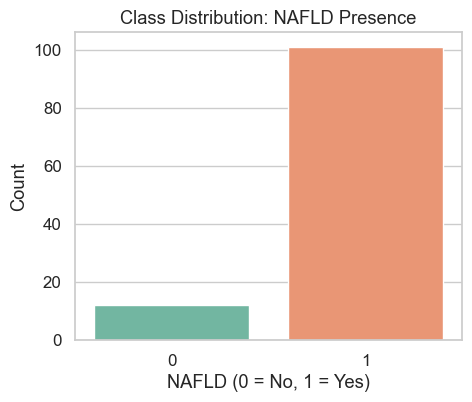

In [12]:
# Class distribution
plt.figure(figsize=(5,4))
sns.countplot(x='NAFLD', data=df, palette='Set2')
plt.title('Class Distribution: NAFLD Presence')
plt.xlabel('NAFLD (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

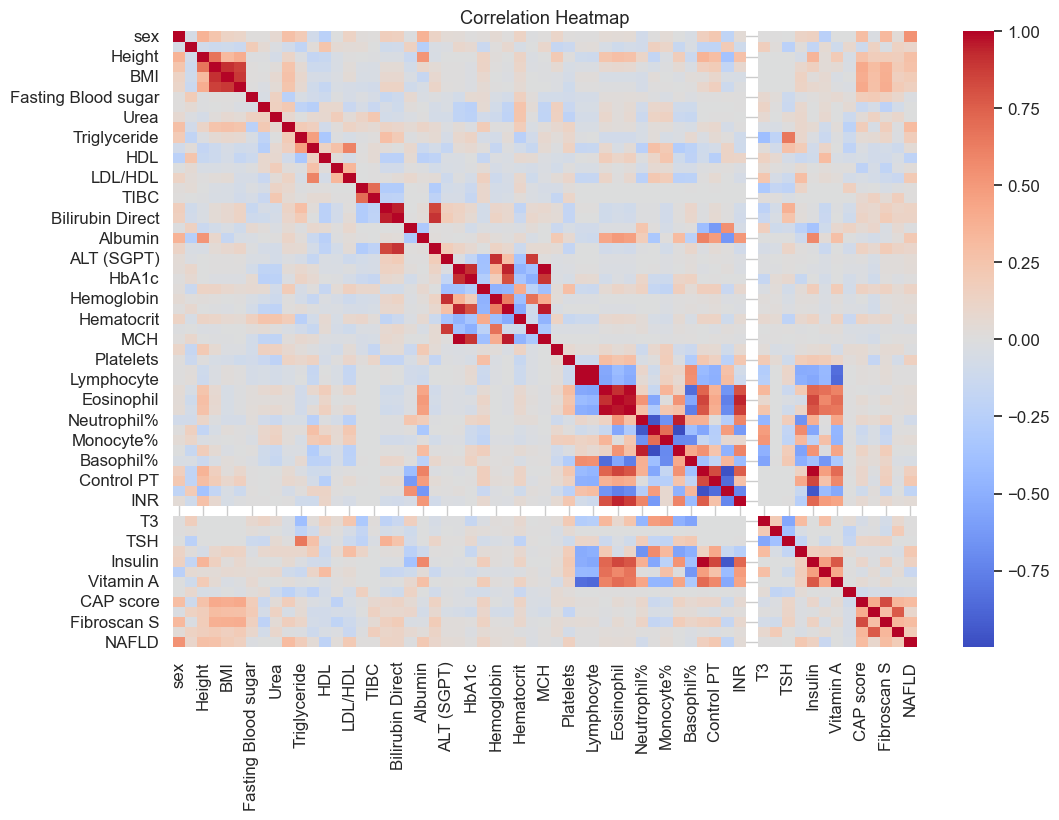

In [13]:
# Correlation heatmap
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [14]:
X = df.drop('NAFLD', axis=1)
y = df['NAFLD']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, prec, rec, f1, auc])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']).sort_values(by='ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Random Forest,0.913043,0.913043,1.000000,0.954545,0.940476
1,Decision Tree,0.913043,0.952381,0.952381,0.952381,0.726190
3,KNN,0.956522,0.954545,1.000000,0.976744,0.666667
0,Logistic Regression,0.913043,0.952381,0.952381,0.952381,0.571429
4,SVM,0.913043,0.913043,1.000000,0.954545,0.500000


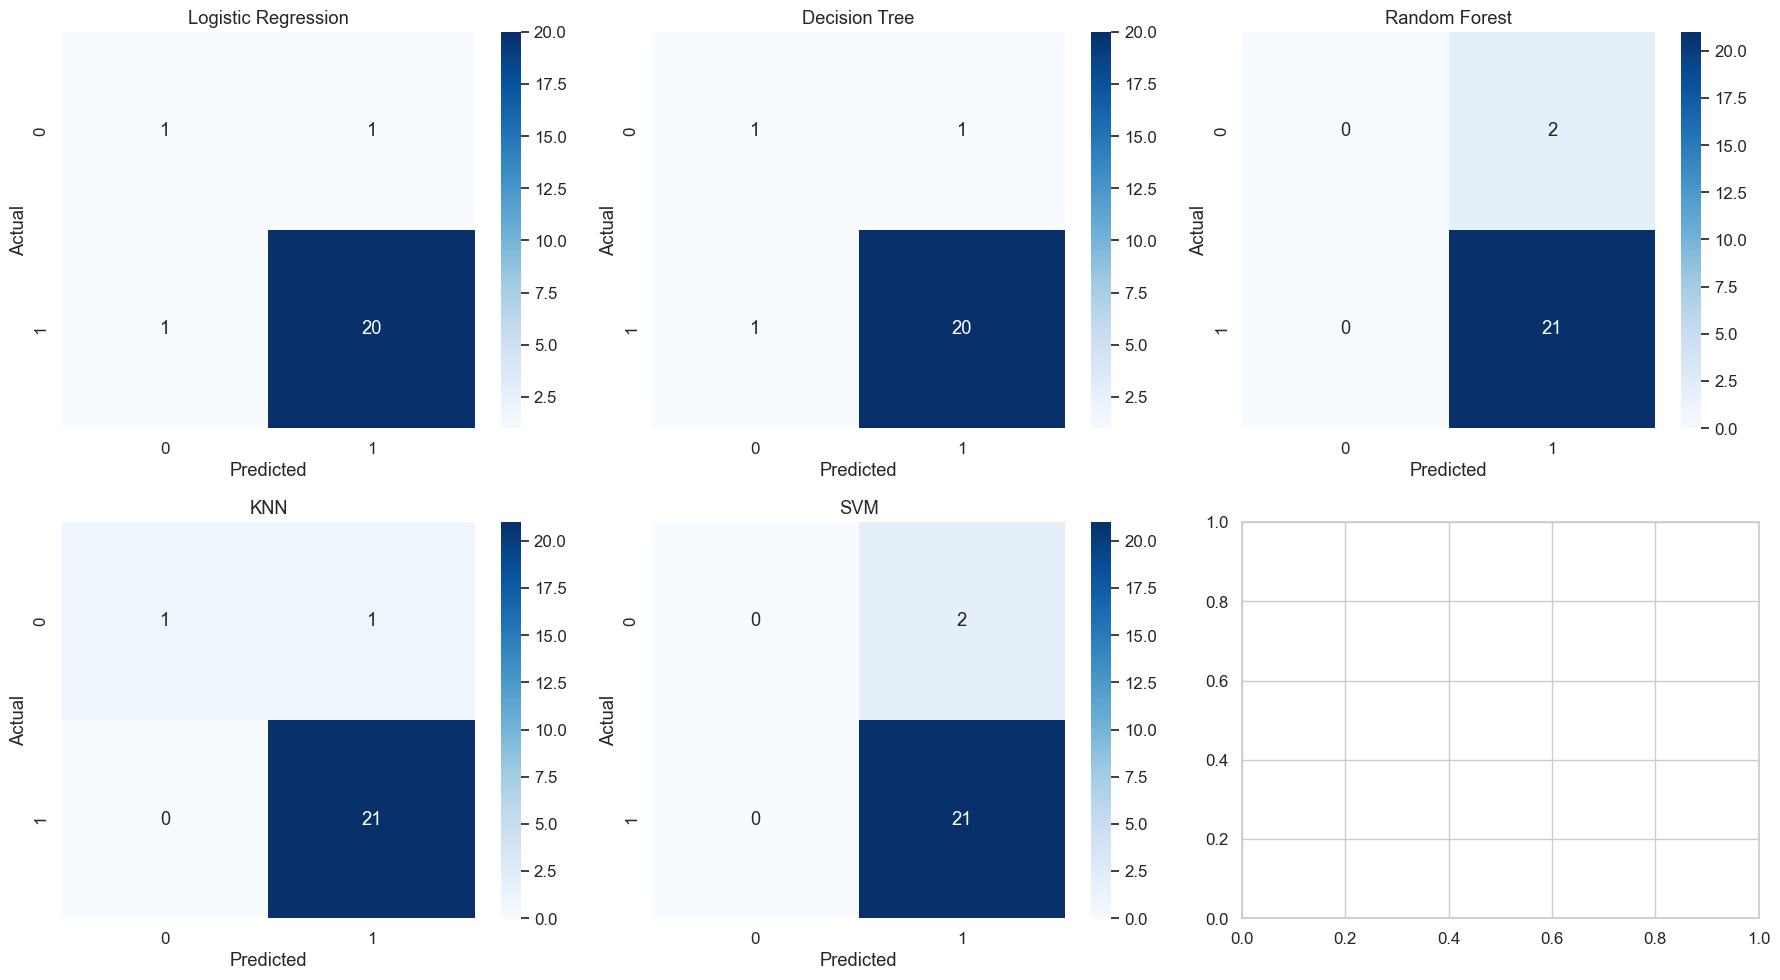

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

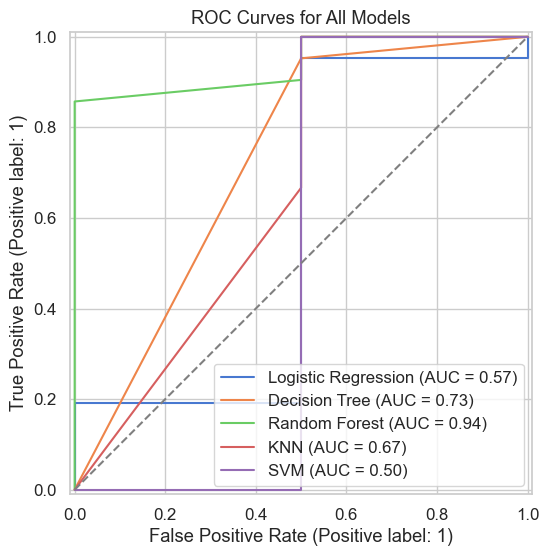

In [17]:
# ROC Curves
plt.figure(figsize=(8,6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=plt.gca(), name=name)
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('ROC Curves for All Models')
plt.show()

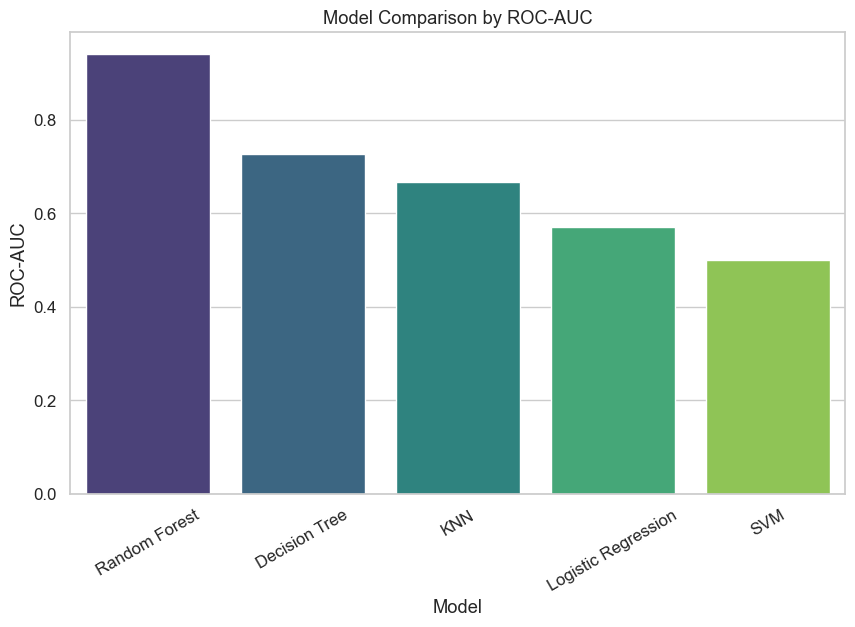

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='ROC-AUC', data=results_df, palette='viridis')
plt.title('Model Comparison by ROC-AUC')
plt.xticks(rotation=30)
plt.show()

In [19]:
best_model_name = results_df.iloc[0, 0]
best_model = models[best_model_name]

cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"{best_model_name} Cross-validation Mean Accuracy: {cv_scores.mean():.4f}")

Random Forest Cross-validation Mean Accuracy: 0.8778


In [20]:
dump(best_model, 'best_model_NAFLD.joblib')
dump(scaler, 'scaler_NAFLD.joblib')
print(f"Saved best model: {best_model_name}")

Saved best model: Random Forest


In [21]:
def predict_NAFLD_risk(sample_data):
    """
    Predicts NAFLD risk based on patient data.
    Input: pandas DataFrame (single row) with same features as training data.
    Output: 'Low Risk of NAFLD' or 'High Risk of NAFLD'
    """
    from joblib import load
    model = load('best_model_NAFLD.joblib')
    scaler = load('scaler_NAFLD.joblib')

    sample_scaled = scaler.transform(sample_data)
    pred = model.predict(sample_scaled)[0]

    return "High Risk of NAFLD" if pred == 1 else "Low Risk of NAFLD"

In [22]:
# Use a sample from the dataset
sample = X_test.iloc[[0]]
prediction = predict_NAFLD_risk(sample)
print(prediction)

High Risk of NAFLD


In [23]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\AppliedMachineLearning Project\Non-alcoholic fatty liver dataset.csv")

In [ ]:
X = df.drop('NAFLD', axis=1)
y = df['NAFLD']

In [25]:
print(X.columns.tolist())
print(len(X.columns))

['sex', 'Age', 'Height', 'Weight', 'BMI', 'waist', 'Fasting Blood sugar', 'Cre', 'Urea', 'Uric Acid', 'Triglyceride', 'Cholestrol', 'HDL', 'LDL', 'LDL/HDL', 'Iron', 'TIBC', 'Bilirubin total', 'Bilirubin Direct', 'GGT', 'Albumin', 'AST (SGOT)', 'ALT (SGPT)', 'Alkaline Phosphatase', 'HbA1c', 'WBC', 'Hemoglobin', 'RBC', 'Hematocrit', 'MCV', 'MCH', 'MCHC', 'Platelets', 'Neutrophil', 'Lymphocyte', 'Monocyte', 'Eosinophil', 'basophil', 'Neutrophil%', 'Lymphocyte%', 'Monocyte%', 'Eosinophil%', 'Basophil%', 'Patient PT', 'Control PT', 'Activity%', 'INR', 'ESR', 'T3', 'T4', 'TSH', 'Ferritin', 'Insulin', 'CRP ', 'Vitamin A', 'OH', 'CAP score', 'E score', 'Fibroscan S', 'Fibroscan F']
60


In [26]:
from joblib import dump

dump(best_model, 'best_model_NAFLD.joblib')
dump(scaler, 'scaler_NAFLD.joblib')

print("Model and scaler saved successfully")

Model and scaler saved successfully
